<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 18px 24px;
    border-radius: 12px;
    text-align: center;
    margin: 18px 0;
    box-shadow: 0 5px 14px rgba(0,0,0,0.22);
">
    <h2 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 26px;
        font-weight: 800;
        margin: 0;
    ">
         Install Required Libraries
    </h2>
</div>

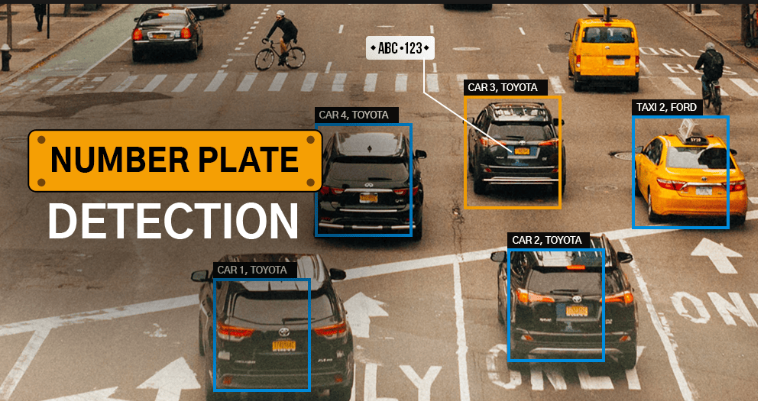

In [ ]:
!pip install ultralytics opencv-python -q

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Import Libraries and Set Dataset Paths
    </h1>
</div>

In [ ]:
from ultralytics import YOLO
import os
import cv2

DATASET_DIR = "/kaggle/input/datasets/ferozahmedds/license-plate-detection-yolo26/License Plate Detection.v1-license-plate-detection-yolo26-v1.yolov8"

DATA_YAML = DATASET_DIR + "/data.yaml"

VIDEO_PATH = "/kaggle/input/datasets/ferozahmedds/license-plate-detection-yolo26/License Plate Detection Test.mp4"

print("Data YAML exists:", os.path.exists(DATA_YAML))
print("Video exists:", os.path.exists(VIDEO_PATH))
print("DATA_YAML:", DATA_YAML)
print("VIDEO_PATH:", VIDEO_PATH)

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Prepare Fixed YOLO Data Configuration
    </h1>
</div>

In [ ]:
import yaml
import os

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("Original data.yaml:")
print(data)

fixed_data = data.copy()

fixed_data["train"] = DATASET_DIR + "/train/images"
fixed_data["val"] = DATASET_DIR + "/valid/images"

if os.path.exists(DATASET_DIR + "/test/images"):
    fixed_data["test"] = DATASET_DIR + "/test/images"

FIXED_DATA_YAML = "/kaggle/working/data_fixed.yaml"

with open(FIXED_DATA_YAML, "w") as f:
    yaml.dump(fixed_data, f)

print("Fixed data.yaml saved at:", FIXED_DATA_YAML)

with open(FIXED_DATA_YAML, "r") as f:
    print(f.read())

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Train YOLOv8 License Plate Detection Model
    </h1>
</div>

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

train_results = model.train(
    data=FIXED_DATA_YAML,
    epochs=10,
    imgsz=416,
    batch=16,
    project="/kaggle/working/license_plate_training",
    name="yolov8m_license_plate",
    exist_ok=True
)

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Load and Verify the Trained Model
    </h1>
</div>

In [ ]:
BEST_MODEL_PATH = "/kaggle/working/license_plate_training/yolov8m_license_plate/weights/best.pt"

print("Best model exists:", os.path.exists(BEST_MODEL_PATH))
print("Best model path:", BEST_MODEL_PATH)

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Generate Custom License Plate Detection Video
    </h1>
</div>

In [ ]:
import cv2
from ultralytics import YOLO
from IPython.display import Video, display
import os

BEST_MODEL_PATH = "/kaggle/working/license_plate_training/yolov8m_license_plate/weights/best.pt"
VIDEO_PATH = "/kaggle/input/datasets/ferozahmedds/license-plate-detection-yolo26/License Plate Detection Test.mp4"
OUTPUT_VIDEO = "/kaggle/working/license_plate_custom_output.mp4"

model = YOLO(BEST_MODEL_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Could not open video file.")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

if fps == 0:
    fps = 30

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

box_color = (0, 255, 255)
text_color = (0, 0, 0)
box_thickness = 3
font_scale = 0.7
font_thickness = 2
confidence_threshold = 0.25

while True:
    ret, frame = cap.read()
    
    if not ret:
        break
    
    results = model.predict(
        source=frame,
        conf=confidence_threshold,
        verbose=False
    )
    
    for result in results:
        boxes = result.boxes
        
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            class_name = model.names[cls_id]
            
            label = f"{class_name} {conf:.2f}"
            
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                box_color,
                box_thickness
            )
            
            text_size, baseline = cv2.getTextSize(
                label,
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                font_thickness
            )
            
            text_width, text_height = text_size
            
            label_y1 = max(y1 - text_height - baseline - 10, 0)
            label_y2 = y1
            
            cv2.rectangle(
                frame,
                (x1, label_y1),
                (x1 + text_width + 10, label_y2),
                box_color,
                -1
            )
            
            cv2.putText(
                frame,
                label,
                (x1 + 5, y1 - 7),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                text_color,
                font_thickness
            )
    
    out.write(frame)

cap.release()
out.release()

print("Output saved:", OUTPUT_VIDEO)
print("File exists:", os.path.exists(OUTPUT_VIDEO))

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Convert and Display Browser-Compatible Output Video
    </h1>
</div>

In [ ]:
import os
from IPython.display import Video, display, FileLink

INPUT_VIDEO = "/kaggle/working/license_plate_custom_output.mp4"
PLAYABLE_VIDEO = "/kaggle/working/license_plate_custom_output_playable.mp4"

if not os.path.exists(INPUT_VIDEO):
    raise FileNotFoundError("Input video not found. Run the detection cell first.")

if os.path.getsize(INPUT_VIDEO) == 0:
    raise RuntimeError("Input video file is empty. Check the detection output cell.")

!ffmpeg -y -i "$INPUT_VIDEO" -vcodec libx264 -pix_fmt yuv420p -movflags +faststart "$PLAYABLE_VIDEO" -loglevel error

print("Playable video created:", PLAYABLE_VIDEO)
print("File exists:", os.path.exists(PLAYABLE_VIDEO))
print("File size MB:", round(os.path.getsize(PLAYABLE_VIDEO) / (1024 * 1024), 2))

display(Video(PLAYABLE_VIDEO, embed=True, width=900))
display(FileLink(PLAYABLE_VIDEO))

<div style="
    background: linear-gradient(90deg, #8f2f0b, #ff8c2a);
    padding: 22px 28px;
    border-radius: 14px;
    text-align: center;
    margin: 20px 0 18px 0;
    box-shadow: 0 6px 16px rgba(0,0,0,0.25);
">
    <h1 style="
        color: white;
        font-family: Arial, sans-serif;
        font-size: 32px;
        font-weight: 800;
        letter-spacing: 1px;
        margin: 0;
    ">
        Thank You Very Much
    </h1>
</div>